# Education Statistics Project

## Question

How do primary and lower secondary enrollment rates compare across selected countries, and how does education spending relate to enrollment outcomes from 2010 to 2014?


## Data Loading


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = PROJECT_ROOT / "datasets" / "EdStats"
CHARTS_DIR = PROJECT_ROOT / "exports" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df = pd.read_csv(
    DATA_DIR / "EdStatsData.csv",
    low_memory=False
)
df.shape


(886930, 70)

## Data Availability

Define the countries and indicators used in the analysis, then check whether the selected 2010-2014 window has enough coverage for comparison. Adult and youth literacy indicators are checked for availability, but the final analysis focuses on enrollment and education spending.


In [3]:
countries = [
    "Nigeria",
    "Ghana",
    "South Africa",
    "United States",
    "Canada",
    "China",
    "Japan",
    "India",
    "Germany",
    "Brazil"
]

analysis_countries = [
    "Brazil",
    "Germany",
    "Ghana",
    "India",
    "Japan",
    "United States"
]

indicators = [
    "Adult literacy rate, population 15+ years, both sexes (%)",
    "Youth literacy rate, population 15-24 years, both sexes (%)",
    "Adjusted net enrolment rate, primary, both sexes (%)",
    "Adjusted net enrolment rate, lower secondary, both sexes (%)"
]


In [4]:
project_df = df[
    df["Country Name"].isin(countries)
    &
    df["Indicator Name"].isin(indicators)
]

project_df.shape

(40, 70)

In [5]:
years = [str(y) for y in range(2010, 2015)]

project_df.groupby("Indicator Name")[years].count()


,2010,2011,2012,2013,2014
Indicator Name,,,,,
"Adjusted net enrolment rate, lower secondary, both sexes (%)",2,3,3,5,2
"Adjusted net enrolment rate, primary, both sexes (%)",5,6,7,7,5
"Adult literacy rate, population 15+ years, both sexes (%)",4,3,2,1,2
"Youth literacy rate, population 15-24 years, both sexes (%)",4,3,2,1,2


In [6]:
spending_df = df[
    df["Indicator Name"].str.contains(
        "expenditure",
        case=False,
        na=False
    )
]

coverage = (
    spending_df
    .groupby("Indicator Name")[["2010","2011","2012","2013","2014"]]
    .count()
    .sum(axis=1)
    .sort_values(ascending=False)
)

coverage.head(20)

Indicator Name
Government expenditure on education as % of GDP (%)                                      569
Expenditure on education as % of total government expenditure (%)                        556
Expenditure on tertiary as % of government expenditure on education (%)                  520
Expenditure on secondary as % of government expenditure on education (%)                 494
Expenditure on primary as % of government expenditure on education (%)                   490
Government expenditure per primary student as % of GDP per capita (%)                    489
Current expenditure as % of total expenditure in primary public institutions (%)         452
Current expenditure as % of total expenditure in secondary public institutions (%)       448
Government expenditure per tertiary student as % of GDP per capita (%)                   434
Government expenditure per secondary student as % of GDP per capita (%)                  433
Current expenditure as % of total expenditure in public

## Enrollment Analysis

Focus on primary and lower secondary enrollment for the countries with usable coverage in the 2010-2014 window.


In [7]:
enrollment_df = project_df[
    project_df["Indicator Name"].isin([
        "Adjusted net enrolment rate, primary, both sexes (%)",
        "Adjusted net enrolment rate, lower secondary, both sexes (%)"
    ])
]

enrollment_df[
    ["Country Name", "Indicator Name", "2010", "2011", "2012", "2013", "2014"]
]

,Country Name,Indicator Name,2010,2011,2012,2013,2014
186915,Brazil,"Adjusted net enrolment rate, lower secondary, ...",NaN,74.373451,73.733627,82.618088,NaN
186919,Brazil,"Adjusted net enrolment rate, primary, both sex...",NaN,95.697182,95.513748,93.779037,94.715057
219900,Canada,"Adjusted net enrolment rate, lower secondary, ...",NaN,NaN,NaN,NaN,NaN
219904,Canada,"Adjusted net enrolment rate, primary, both sex...",NaN,NaN,99.477478,99.456741,NaN
241890,China,"Adjusted net enrolment rate, lower secondary, ...",NaN,NaN,NaN,NaN,NaN
241894,China,"Adjusted net enrolment rate, primary, both sex...",NaN,NaN,NaN,NaN,NaN
355505,Germany,"Adjusted net enrolment rate, lower secondary, ...",NaN,NaN,NaN,NaN,NaN
355509,Germany,"Adjusted net enrolment rate, primary, both sex...",99.612267,99.642090,99.595734,99.847969,99.845421
359170,Ghana,"Adjusted net enrolment rate, lower secondary, ...",NaN,NaN,NaN,50.278381,51.623199
359174,Ghana,"Adjusted net enrolment rate, primary, both sex...",NaN,83.850082,82.188591,86.831657,89.312286


In [8]:
years = ["2010", "2011", "2012", "2013", "2014"]

analysis_df = enrollment_df[
    enrollment_df["Country Name"].isin(analysis_countries)
]

long_df = analysis_df.melt(
    id_vars=["Country Name", "Indicator Name"],
    value_vars=years,
    var_name="Year",
    value_name="Enrollment Rate"
)

long_df = long_df.dropna()

long_df.head()

,Country Name,Indicator Name,Year,Enrollment Rate
3,Germany,"Adjusted net enrolment rate, primary, both sex...",2010,99.612267
7,India,"Adjusted net enrolment rate, primary, both sex...",2010,96.192810
8,Japan,"Adjusted net enrolment rate, lower secondary, ...",2010,99.922028
9,Japan,"Adjusted net enrolment rate, primary, both sex...",2010,99.943512
10,United States,"Adjusted net enrolment rate, lower secondary, ...",2010,86.635513


In [9]:
primary_df = long_df[
    long_df["Indicator Name"] ==
    "Adjusted net enrolment rate, primary, both sexes (%)"
]

primary_df.head()

,Country Name,Indicator Name,Year,Enrollment Rate
3,Germany,"Adjusted net enrolment rate, primary, both sex...",2010,99.612267
7,India,"Adjusted net enrolment rate, primary, both sex...",2010,96.192810
9,Japan,"Adjusted net enrolment rate, primary, both sex...",2010,99.943512
11,United States,"Adjusted net enrolment rate, primary, both sex...",2010,94.795822
13,Brazil,"Adjusted net enrolment rate, primary, both sex...",2011,95.697182


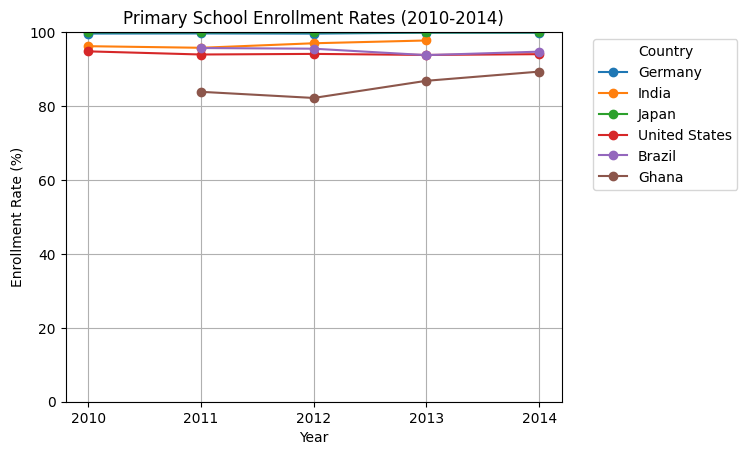

In [10]:
import matplotlib.pyplot as plt

for country in primary_df["Country Name"].unique():
    country_data = primary_df[
        primary_df["Country Name"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Enrollment Rate"],
        marker="o",
        label=country
    )

plt.title("Primary School Enrollment Rates (2010-2014)")
plt.xlabel("Year")
plt.ylabel("Enrollment Rate (%)")
plt.ylim(0, 100)
plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True)

plt.grid(True)

plt.savefig(

    CHARTS_DIR / "primary_enrollment.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Findings

Primary school enrollment rates remained near universal in Japan and Germany throughout 2010–2014.

India showed steady improvement from approximately 96% to 98%.

Ghana recorded the largest increase, rising from roughly 84% to 89% by 2014.

Brazil and the United States maintained relatively stable enrollment rates around 94–96%.

In [11]:
secondary_df = long_df[
    long_df["Indicator Name"] ==
    "Adjusted net enrolment rate, lower secondary, both sexes (%)"
]

secondary_df.head()

,Country Name,Indicator Name,Year,Enrollment Rate
8,Japan,"Adjusted net enrolment rate, lower secondary, ...",2010,99.922028
10,United States,"Adjusted net enrolment rate, lower secondary, ...",2010,86.635513
12,Brazil,"Adjusted net enrolment rate, lower secondary, ...",2011,74.373451
20,Japan,"Adjusted net enrolment rate, lower secondary, ...",2011,99.857643
22,United States,"Adjusted net enrolment rate, lower secondary, ...",2011,87.674263


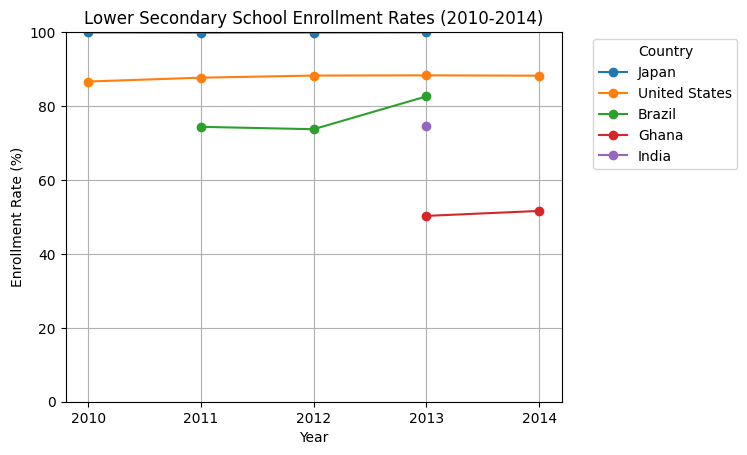

In [12]:
for country in secondary_df["Country Name"].unique():
    country_data = secondary_df[
        secondary_df["Country Name"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Enrollment Rate"],
        marker="o",
        label=country
    )

plt.title("Lower Secondary School Enrollment Rates (2010-2014)")
plt.xlabel("Year")
plt.ylabel("Enrollment Rate (%)")

plt.ylim(0, 100)

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.savefig(

    CHARTS_DIR / "secondary_enrollment.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Secondary Enrollment Findings

While primary school enrollment is high across most countries, larger differences emerge at the secondary level.

Japan maintains nearly universal enrollment throughout the period.

The United States remains relatively stable around 88%.

Brazil improves from approximately 74% to 83%.

Ghana records the lowest secondary enrollment rates, remaining near 50%.

The results suggest that maintaining student participation beyond primary school remains a challenge for some developing economies.

## Spending Analysis

Use government expenditure on education as a percentage of GDP to compare spending patterns across the same period.


In [13]:
spending_indicator = (
    "Government expenditure on education as % of GDP (%)"
)

spending_df = df[
    (df["Country Name"].isin(countries))
    &
    (df["Indicator Name"] == spending_indicator)
]

spending_df[
    ["Country Name",
     "2010", "2011", "2012", "2013", "2014"]
]

,Country Name,2010,2011,2012,2013,2014
188175,Brazil,5.64277,5.74579,5.79516,5.99395,NaN
221160,Canada,5.36092,5.28122,NaN,NaN,NaN
243150,China,NaN,NaN,NaN,NaN,NaN
356765,Germany,4.91379,4.81336,4.93020,4.92842,4.95219
360430,Ghana,5.54060,8.14097,7.91914,6.09819,6.17855
415405,India,3.42416,3.83866,3.86588,3.84236,NaN
448390,Japan,3.63580,3.64515,3.69533,3.66506,3.59184
620645,Nigeria,NaN,NaN,NaN,NaN,NaN
737925,South Africa,5.71644,5.95843,6.37936,6.02067,6.02955
847875,United States,5.42707,5.21150,5.20087,4.93013,5.38078


In [14]:
spending_long = spending_df.melt(
    id_vars=["Country Name"],
    value_vars=["2010", "2011", "2012", "2013", "2014"],
    var_name="Year",
    value_name="Education Spending (% GDP)"
)

spending_long = spending_long.dropna()

spending_long.head()

,Country Name,Year,Education Spending (% GDP)
0,Brazil,2010,5.64277
1,Canada,2010,5.36092
3,Germany,2010,4.91379
4,Ghana,2010,5.54060
5,India,2010,3.42416


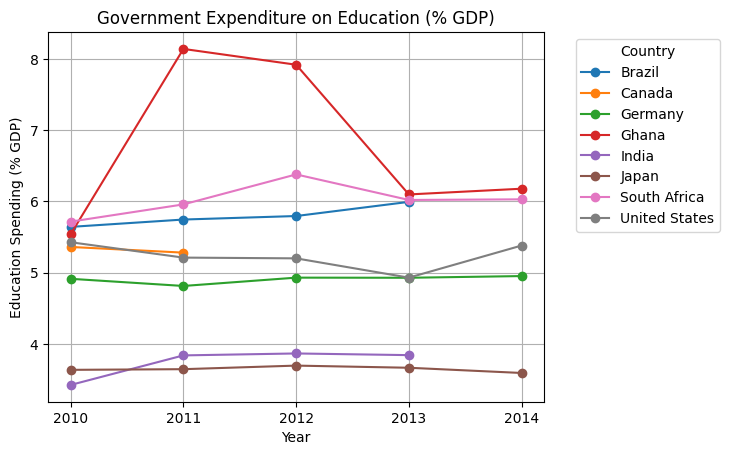

In [15]:
for country in spending_long["Country Name"].unique():

    country_data = spending_long[
        spending_long["Country Name"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Education Spending (% GDP)"],
        marker="o",
        label=country
    )

plt.title("Government Expenditure on Education (% GDP)")
plt.xlabel("Year")
plt.ylabel("Education Spending (% GDP)")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.savefig(

    CHARTS_DIR / "education_spending_gdp.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Spending vs Enrollment

Does spending more on education lead to higher enrollment rates?

To investigate this, we compare:

- Government expenditure on education (% GDP)
- Primary school enrollment rates

for selected countries between 2010 and 2014.

In [16]:
primary_avg = (
    primary_df
    .groupby("Country Name")["Enrollment Rate"]
    .mean()
    .round(2)
)

spending_avg = (
    spending_long
    .groupby("Country Name")["Education Spending (% GDP)"]
    .mean()
    .round(2)
)

comparison = pd.concat(
    [primary_avg, spending_avg],
    axis=1
)

comparison

,Enrollment Rate,Education Spending (% GDP)
Country Name,,
Brazil,94.93,5.79
Germany,99.71,4.91
Ghana,85.55,6.78
India,96.67,3.74
Japan,99.95,3.65
United States,94.14,5.23
Canada,NaN,5.32
South Africa,NaN,6.02


In [17]:
comparison_clean = comparison.dropna()

comparison_clean

,Enrollment Rate,Education Spending (% GDP)
Country Name,,
Brazil,94.93,5.79
Germany,99.71,4.91
Ghana,85.55,6.78
India,96.67,3.74
Japan,99.95,3.65
United States,94.14,5.23


In [18]:
comparison_clean.corr(numeric_only=True)

,Enrollment Rate,Education Spending (% GDP)
Enrollment Rate,1.000000,-0.826705
Education Spending (% GDP),-0.826705,1.000000


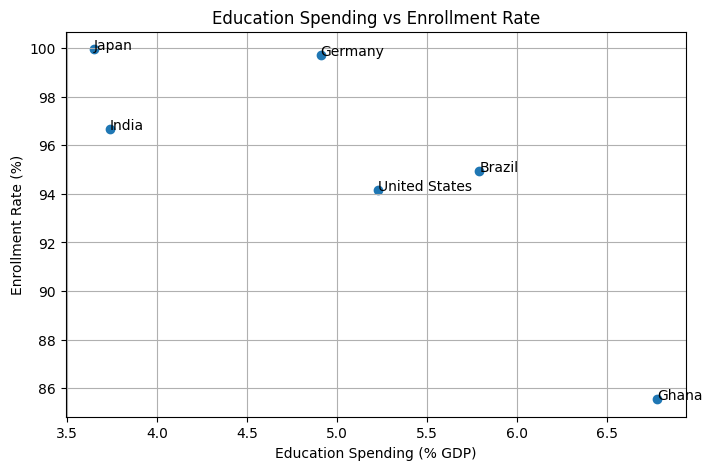

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    comparison_clean["Education Spending (% GDP)"],
    comparison_clean["Enrollment Rate"]
)

for country in comparison_clean.index:
    plt.annotate(
        country,
        (
            comparison_clean.loc[country, "Education Spending (% GDP)"],
            comparison_clean.loc[country, "Enrollment Rate"]
        )
    )

plt.title("Education Spending vs Enrollment Rate")
plt.xlabel("Education Spending (% GDP)")
plt.ylabel("Enrollment Rate (%)")
plt.grid(True)

plt.savefig(

    CHARTS_DIR / "spending_vs_enrollment.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Limitations

- Data availability varies by country, year, and indicator.
- Some countries have incomplete lower secondary enrollment or spending data between 2010 and 2014.
- The spending-versus-enrollment comparison uses country averages over a short period.
- The observed correlation does not imply causation.


# Conclusion

This project analyzed education indicators from the World Bank EdStats dataset for selected countries between 2010 and 2014.

Key findings include:

- Japan and Germany maintained near-universal primary school enrollment rates.
- Ghana devoted the largest share of GDP to education among the countries analyzed.
- A strong negative correlation (-0.83) was observed between average education spending as a percentage of GDP and average primary school enrollment rates.
- This result does not imply causation and may reflect differences in economic development, educational efficiency, demographics, and policy effectiveness.
- Data availability varied significantly across countries and indicators, limiting the scope of the analysis.

Overall, the analysis suggests that higher education spending alone is not sufficient to explain enrollment outcomes. Additional factors should be considered when evaluating educational performance across countries.